In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### Lotka Volterra Model

In [45]:
def lotka_volterra(t, state):
    x, y = state

    alpha = 1.5
    beta = 1.0
    delta = 1.0
    gamma = 3.0

    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y

    return [dxdt, dydt]

Solving the DE

In [46]:
t = np.linspace(0, 15, 1500)

initial_state = [1.0, 1.0]

solution = solve_ivp(
    lotka_volterra,
    [t[0], t[-1]],
    initial_state,
    t_eval=t
)

x = solution.y[0]
y = solution.y[1]

Plot

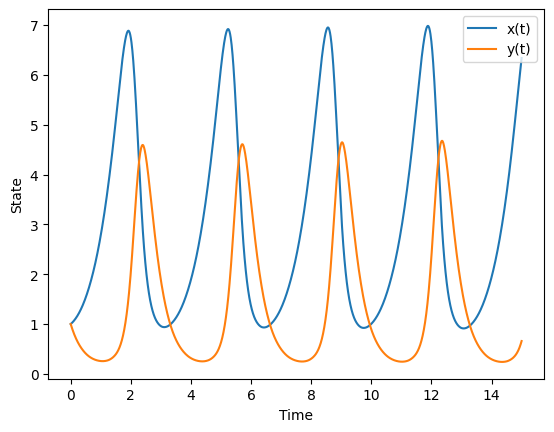

In [47]:
plt.figure()

plt.plot(t, x, label="x(t)")
plt.plot(t, y, label="y(t)")

plt.xlabel("Time")
plt.ylabel("State")
plt.legend()

plt.show()

Phase Potrait

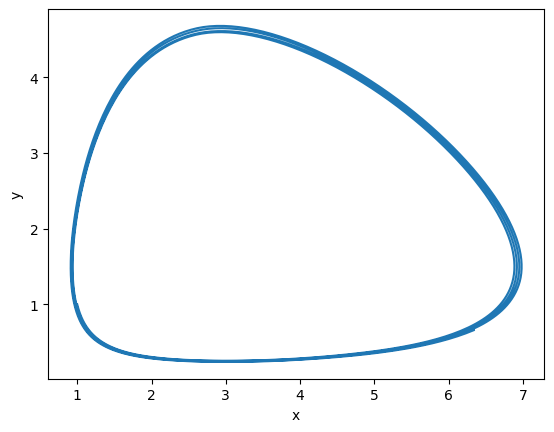

In [48]:
plt.figure()

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")

plt.show()

Creating the matrix X

In [49]:
X = np.column_stack((x, y))

Adding Gaussian Noise

In [50]:
np.random.seed(42)

noise_level = 0.2

X_noisy = X + noise_level * np.random.randn(*X.shape)

Getting the noisy signals

In [51]:
x_noisy = X_noisy[:, 0]
y_noisy = X_noisy[:, 1]

Plotting x with noisy x

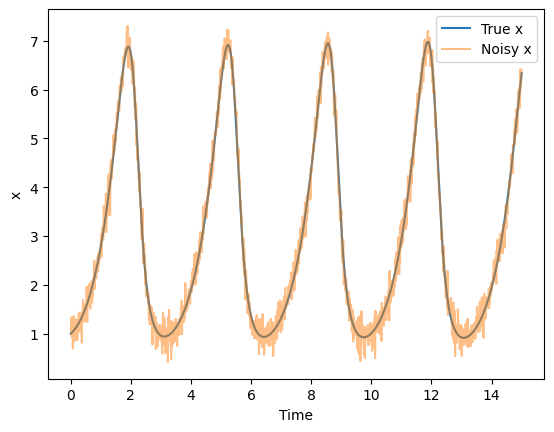

In [52]:
plt.figure()

plt.plot(t, x, label="True x")
plt.plot(t, x_noisy, label="Noisy x", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("x")
plt.legend()

plt.show()

Plotting y with noisy y

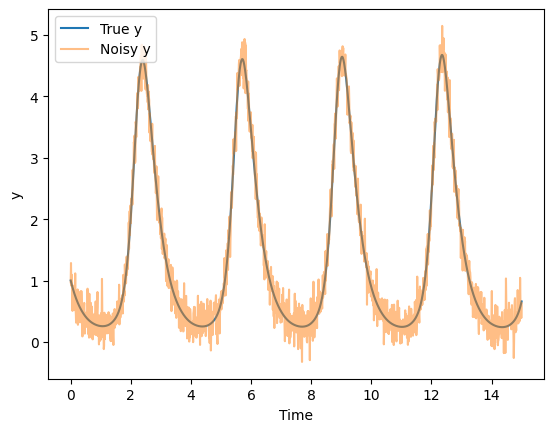

In [53]:
plt.figure()

plt.plot(t, y, label="True y")
plt.plot(t, y_noisy, label="Noisy y", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("y")
plt.legend()

plt.show()

### Differentiating without filtering

In [54]:
dt = t[1] - t[0]

dxdt_est = np.gradient(x_noisy, dt)
dydt_est = np.gradient(y_noisy, dt)

In [55]:
dXdt_est = np.column_stack((dxdt_est, dydt_est))

In [56]:
true_derivatives = np.array([
    lotka_volterra(ti, [xi, yi])
    for ti, xi, yi in zip(t, x, y)
])

dxdt_true = true_derivatives[:, 0]
dydt_true = true_derivatives[:, 1]

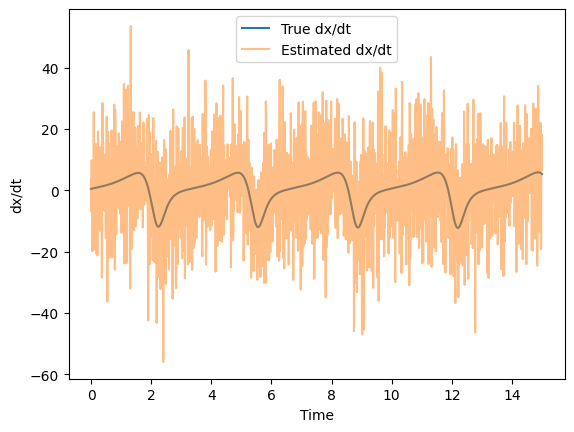

In [57]:
plt.figure()

plt.plot(t, dxdt_true, label="True dx/dt")
plt.plot(t, dxdt_est, label="Estimated dx/dt", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("dx/dt")
plt.legend()

plt.show()

### Creating the Candidate Library

In [58]:
def build_library(X):
    x = X[:, 0]
    y = X[:, 1]

    Theta = np.column_stack((
        np.ones(len(x)),
        x,
        y,
        x**2,
        x*y,
        y**2
    ))

    names = [
        "1",
        "x",
        "y",
        "x^2",
        "xy",
        "y^2"
    ]

    return Theta, names

In [59]:
Theta, library_names = build_library(X_noisy)

In [60]:
print(Theta.shape)

(1500, 6)


### Regression (using not filtered derivative)

In [61]:
Xi, _, _, _ = np.linalg.lstsq(
    Theta,
    dXdt_est,
    rcond=None
)

In [62]:
print(Xi.shape)

(6, 2)


In [63]:
def stlsq(Theta, dXdt, threshold=0.1, max_iter=10):

    Xi, _, _, _ = np.linalg.lstsq(
        Theta,
        dXdt,
        rcond=None
    )

    n_states = dXdt.shape[1]

    for _ in range(max_iter):

        small = np.abs(Xi) < threshold
        Xi[small] = 0

        for j in range(n_states):

            active = Xi[:, j] != 0

            if np.sum(active) == 0:
                continue

            Xi[active, j], _, _, _ = np.linalg.lstsq(
                Theta[:, active],
                dXdt[:, j],
                rcond=None
            )

    return Xi

In [64]:
Xi_sparse = stlsq(
    Theta,
    dXdt_est,
    threshold=0.1,
    max_iter=10
)

In [65]:
print(Xi_sparse)

[[-2.01060325  0.        ]
 [ 2.53607362  0.        ]
 [ 1.55951629 -2.92081372]
 [-0.14909078  0.        ]
 [-0.94931763  0.97929616]
 [-0.39266935  0.        ]]


In [66]:
def print_equations(Xi, names, state_names=("x", "y")):

    for j, state in enumerate(state_names):

        terms = []

        for i, name in enumerate(names):

            coefficient = Xi[i, j]

            if coefficient != 0:
                terms.append(
                    f"{coefficient:.4f} {name}"
                )

        equation = " + ".join(terms)

        print(f"d{state}/dt = {equation}")

In [67]:
print_equations(
    Xi_sparse,
    library_names
)

dx/dt = -2.0106 1 + 2.5361 x + 1.5595 y + -0.1491 x^2 + -0.9493 xy + -0.3927 y^2
dy/dt = -2.9208 y + 0.9793 xy


Testing the equations found by SINDy

In [68]:
def sindy_model(t, state, Xi):

    x, y = state

    theta = np.array([
        1,
        x,
        y,
        x**2,
        x*y,
        y**2
    ])

    derivatives = theta @ Xi

    return derivatives

In [69]:
sindy_solution = solve_ivp(
    lambda t, state: sindy_model(
        t,
        state,
        Xi_sparse
    ),
    [t[0], t[-1]],
    initial_state,
    t_eval=t
)

Getting the x,y found by SINDy

In [70]:
x_sindy = sindy_solution.y[0]
y_sindy = sindy_solution.y[1]

Comparing true and SINDy x

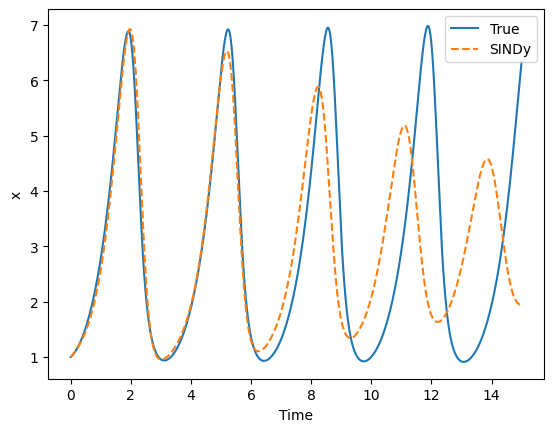

In [71]:
plt.figure()

plt.plot(t, x, label="True")
plt.plot(t, x_sindy, "--", label="SINDy")

plt.xlabel("Time")
plt.ylabel("x")
plt.legend()

plt.show()

Comparing true and SINDy x

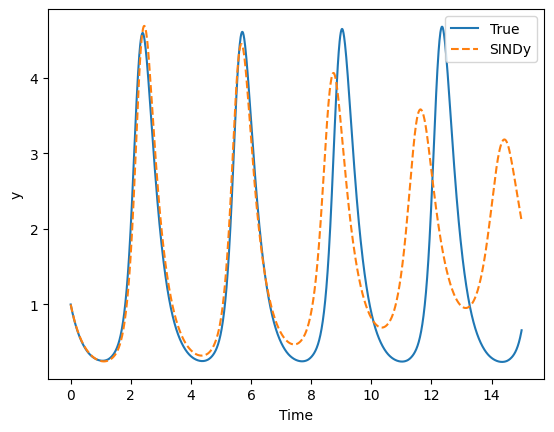

In [72]:
plt.figure()

plt.plot(t, y, label="True")
plt.plot(t, y_sindy, "--", label="SINDy")

plt.xlabel("Time")
plt.ylabel("y")
plt.legend()

plt.show()

Phase potraits

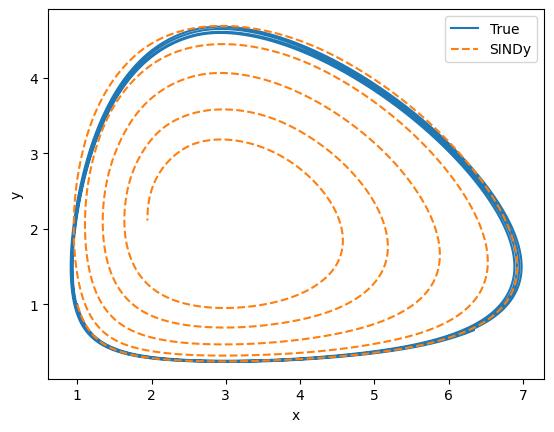

In [73]:
plt.figure()

plt.plot(x, y, label="True")
plt.plot(
    x_sindy,
    y_sindy,
    "--",
    label="SINDy"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

### Testing with Different Noise Levels

In [74]:
# 1. Simulate Lotka-Volterra

solution = solve_ivp(
    lotka_volterra,
    [t[0], t[-1]],
    initial_state,
    t_eval=t
)

x = solution.y[0]
y = solution.y[1]

X = np.column_stack((x, y))


# 2. Add noise

X_noisy = (
    X
    + noise_level
    * np.random.randn(*X.shape)
)


# 3. Estimate derivatives

dt = t[1] - t[0]

dXdt_est = np.column_stack((
    np.gradient(X_noisy[:, 0], dt),
    np.gradient(X_noisy[:, 1], dt)
))


# 4. Candidate library

Theta, names = build_library(X_noisy)


# 5. Sparse regression

Xi_sparse = stlsq(
    Theta,
    dXdt_est,
    threshold=0.1
)


# 6. Print equations

print_equations(
    Xi_sparse,
    names
)


# 7. Simulate discovered model

sindy_solution = solve_ivp(
    lambda t, state:
        sindy_model(
            t,
            state,
            Xi_sparse
        ),
    [t[0], t[-1]],
    initial_state,
    t_eval=t
)

dx/dt = 0.5305 1 + 1.3233 x + -0.3018 y + -0.8988 xy
dy/dt = -2.8542 y + 0.9579 xy


In [75]:
x_sindy = sindy_solution.y[0]
y_sindy = sindy_solution.y[1]

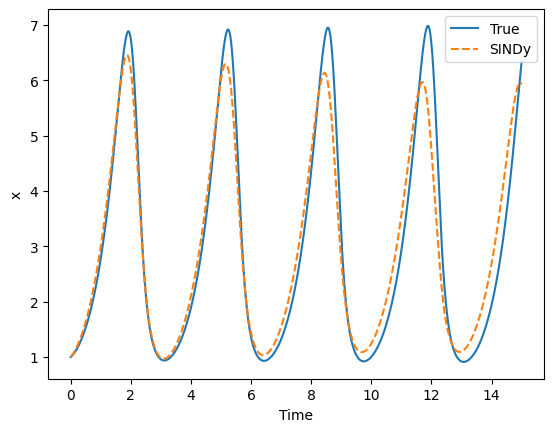

In [76]:
plt.figure()

plt.plot(t, x, label="True")
plt.plot(t, x_sindy, "--", label="SINDy")

plt.xlabel("Time")
plt.ylabel("x")
plt.legend()

plt.show()

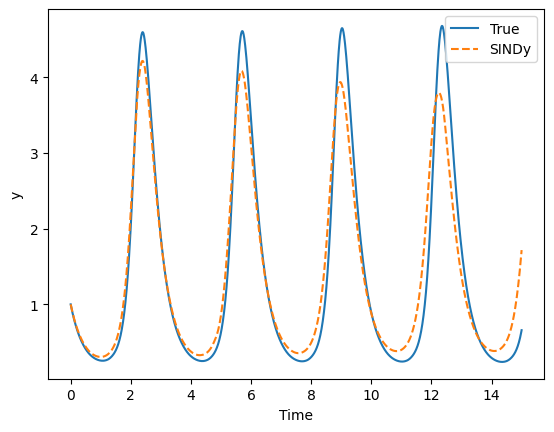

In [77]:
plt.figure()

plt.plot(t, y, label="True")
plt.plot(t, y_sindy, "--", label="SINDy")

plt.xlabel("Time")
plt.ylabel("y")
plt.legend()

plt.show()

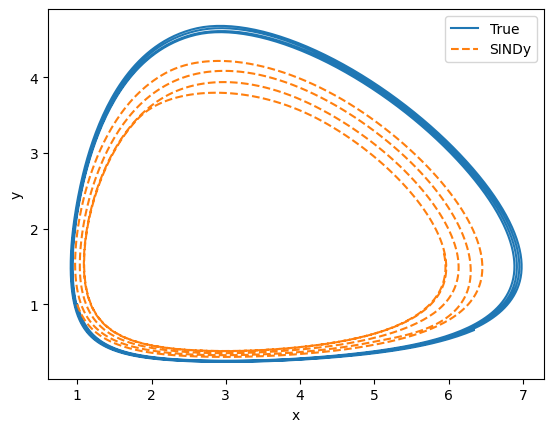

In [78]:
plt.figure()

plt.plot(x, y, label="True")
plt.plot(
    x_sindy,
    y_sindy,
    "--",
    label="SINDy"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

### Testing with multiple noise levels

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def lotka_volterra(t, state):
    x, y = state

    alpha = 1.5
    beta = 1.0
    delta = 1.0
    gamma = 3.0

    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y

    return [dxdt, dydt]


def generate_data(noise_level=0.0, seed=42):

    t = np.linspace(0, 15, 1500)
    initial_state = [1.0, 1.0]

    solution = solve_ivp(
        lotka_volterra,
        [t[0], t[-1]],
        initial_state,
        t_eval=t
    )

    x = solution.y[0]
    y = solution.y[1]

    X = np.column_stack((x, y))

    rng = np.random.default_rng(seed)

    X_noisy = X + noise_level * rng.standard_normal(X.shape)

    x_noisy = X_noisy[:, 0]
    y_noisy = X_noisy[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(t, x, label="True x")
    axes[0].plot(t, x_noisy, alpha=0.6, label="Noisy x")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("x")
    axes[0].set_title("x(t)")
    axes[0].legend()

    axes[1].plot(t, y, label="True y")
    axes[1].plot(t, y_noisy, alpha=0.6, label="Noisy y")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("y")
    axes[1].set_title("y(t)")
    axes[1].legend()

    axes[2].plot(x, y, label="True")
    axes[2].plot(x_noisy, y_noisy, alpha=0.6, label="Noisy")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    axes[2].set_title("Phase portrait")
    axes[2].legend()

    fig.suptitle(f"Noise level = {noise_level}")

    plt.tight_layout()
    plt.show()

    return t, X, X_noisy

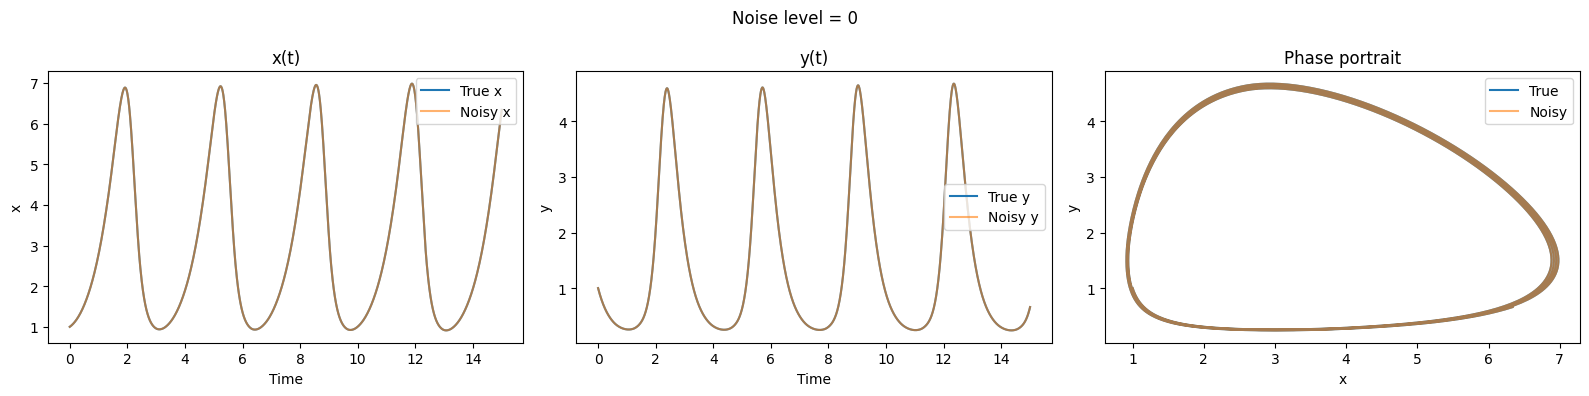

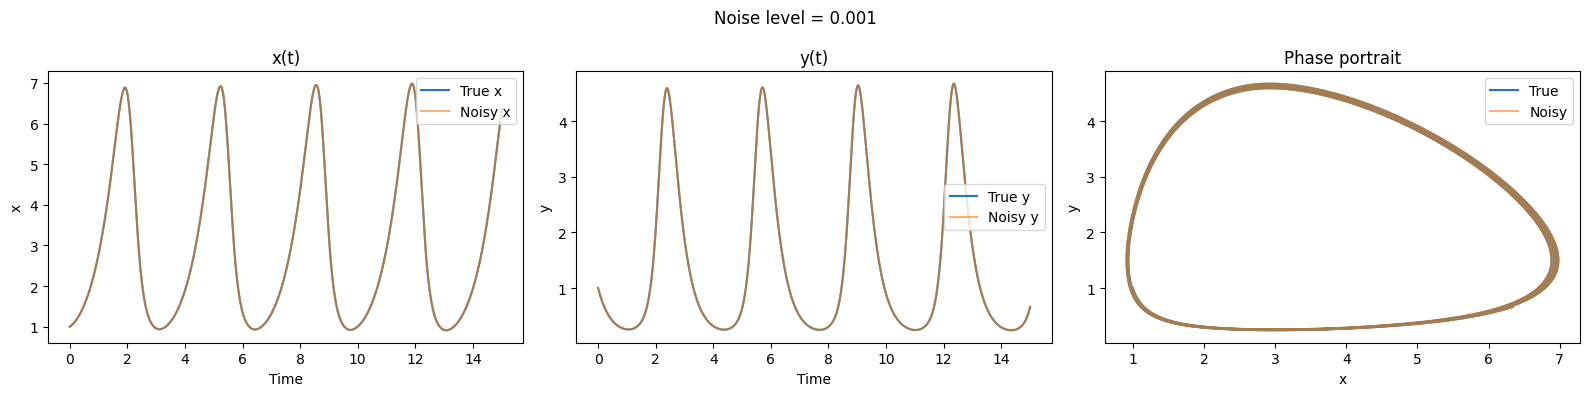

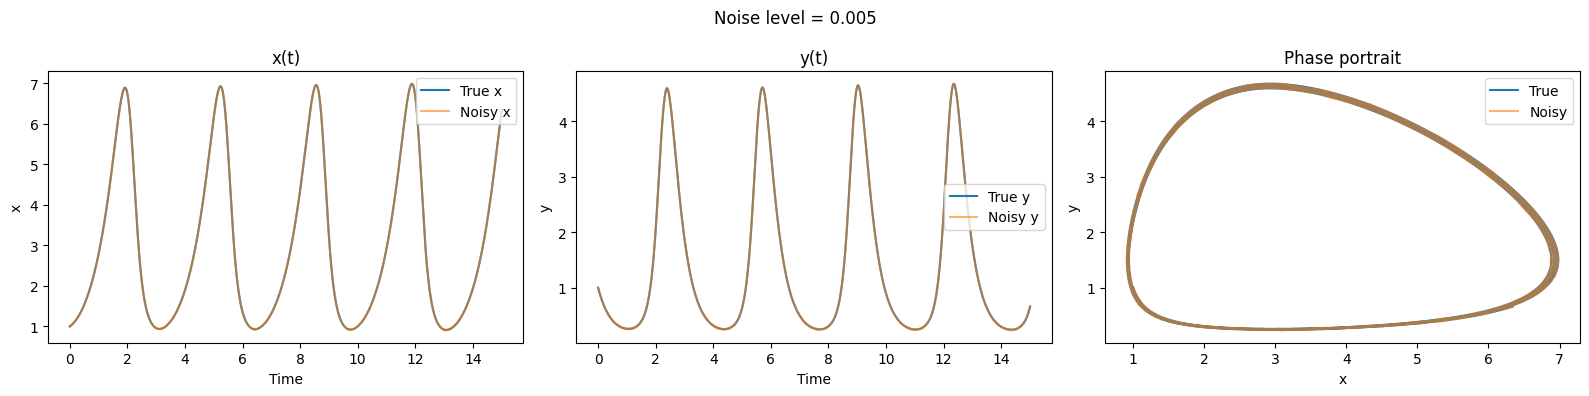

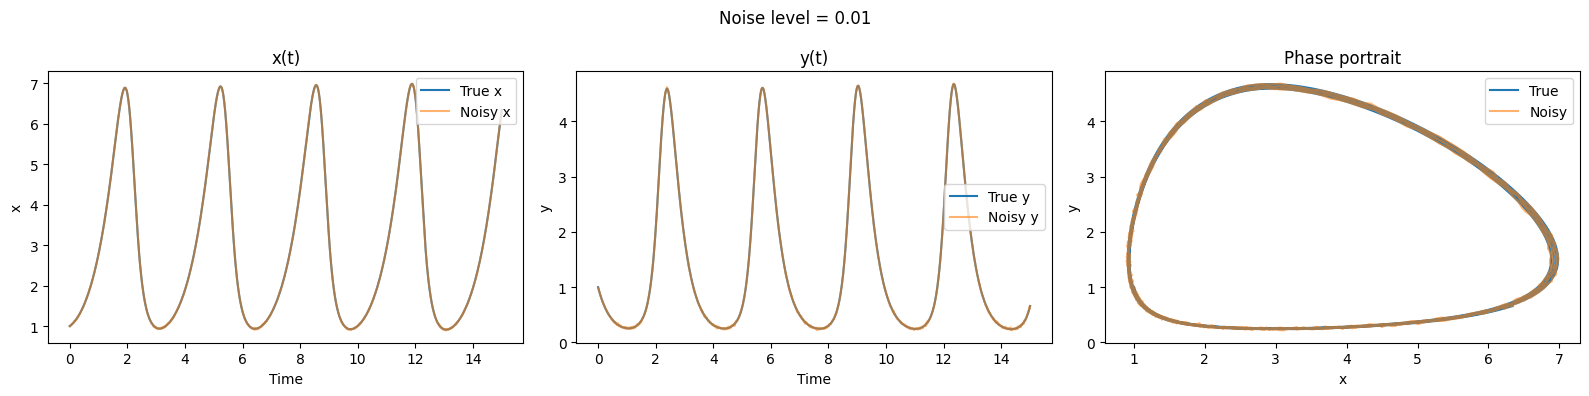

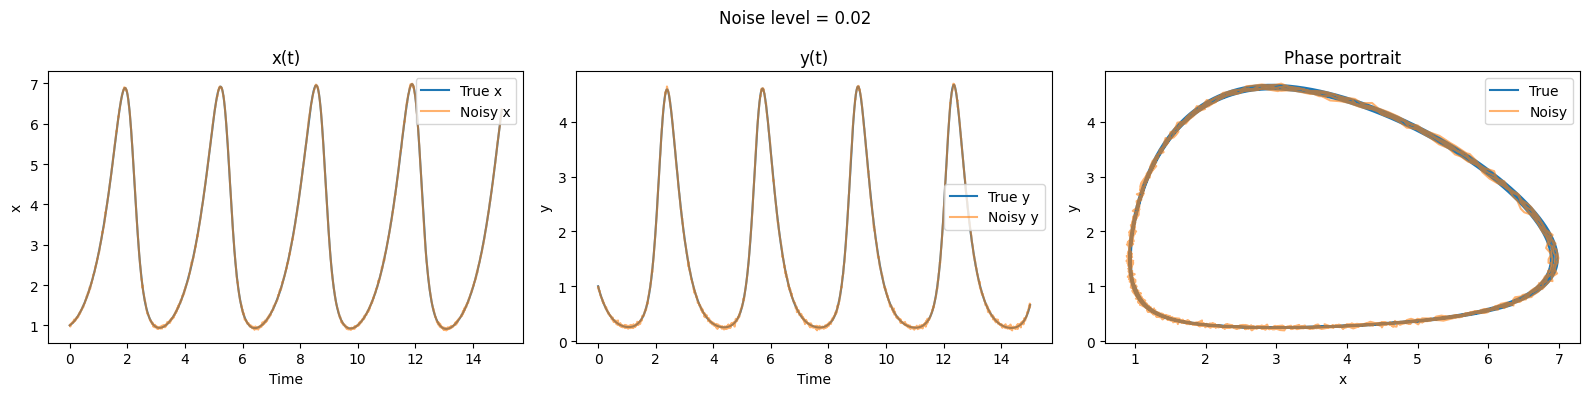

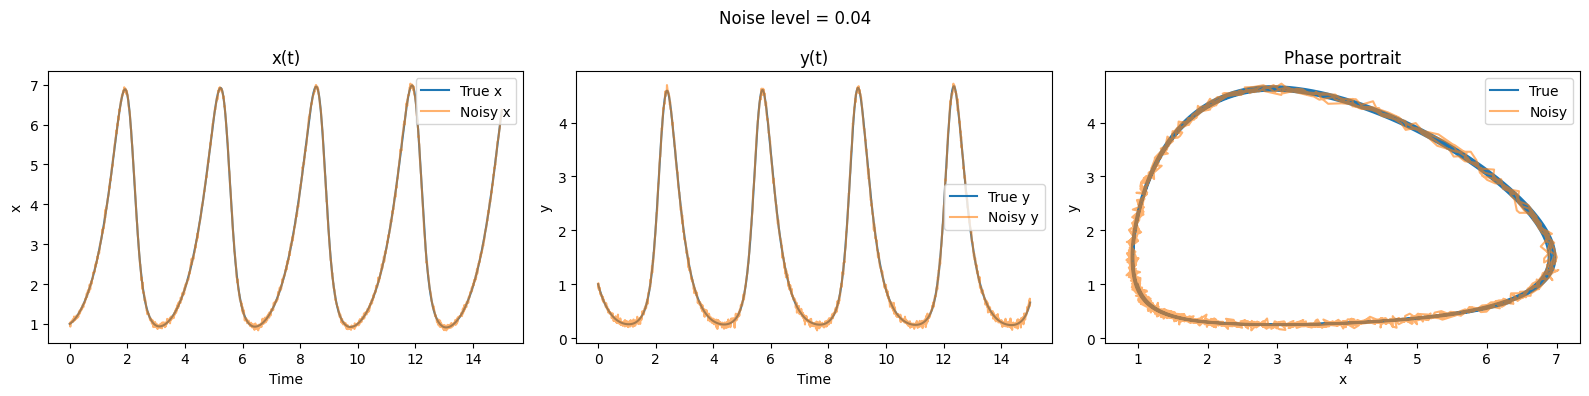

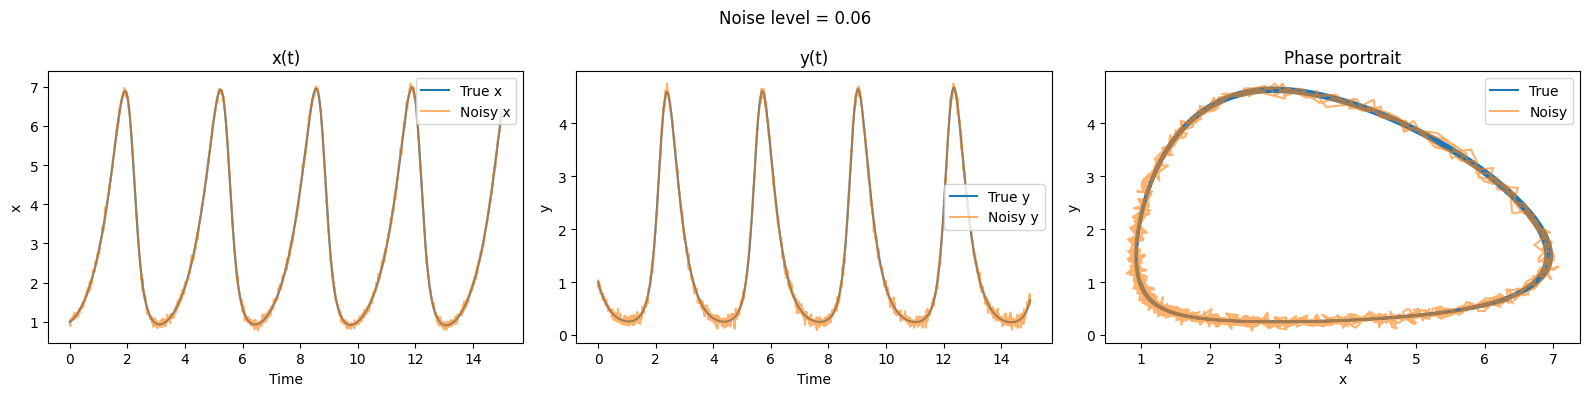

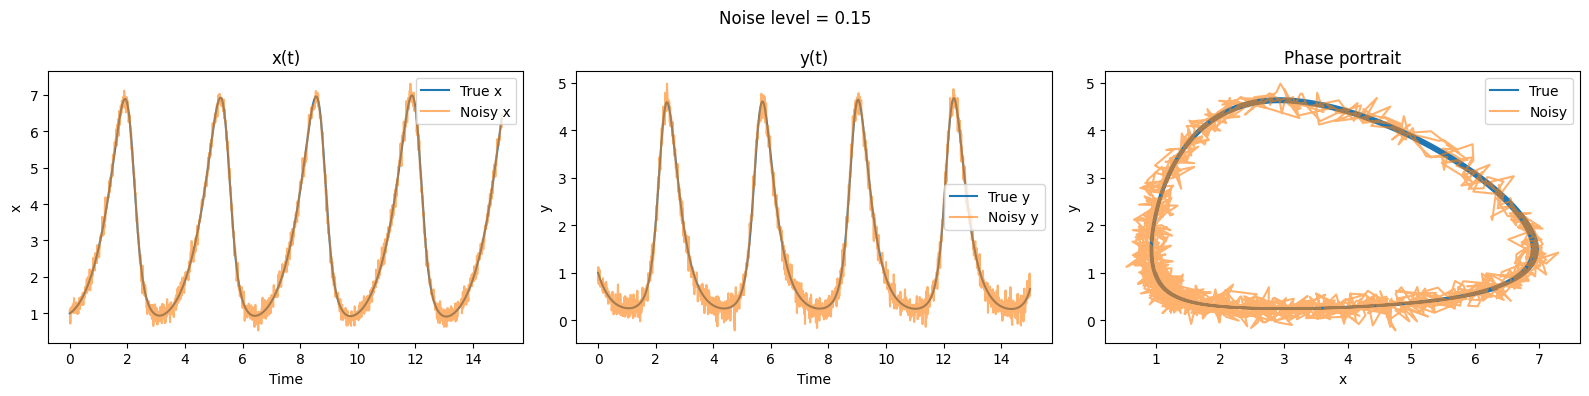

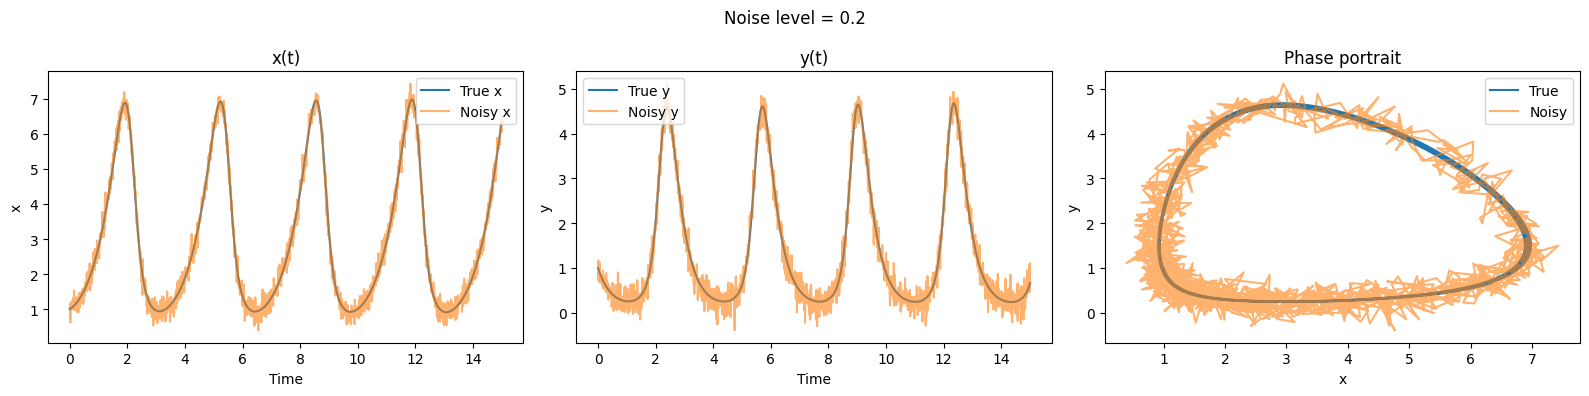

In [84]:
noise_levels = [0, 0.001, 0.005, 0.01, 0.02, 0.04, 0.06,0.15, 0.2]

for noise in noise_levels:
    generate_data(noise_level=noise)